In [1]:
%pip install gensim>=4.1.2

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize, Normalizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from gensim.parsing.preprocessing import STOPWORDS
from gensim.utils import simple_preprocess
from gensim.corpora import Dictionary, MmCorpus
import random
import warnings
import os
import services.utils as ut
import services.model as md
import time
np.random.seed(42)
random.seed(42)

In [3]:
warnings.filterwarnings('ignore', category=UserWarning)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'

In [4]:
data_df = ut.load_data('customer_support_tickets.csv')
if data_df is not None:
    print("Data loaded successfully")
print(data_df.head())

Data loaded successfully
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   

## Preprocessing

In [5]:
data_df = data_df.drop_duplicates(subset=['Ticket Description'], keep='first')
data_df.reset_index(drop=True, inplace=True)

In [6]:
data_df['text'] = data_df['Ticket Description'].fillna('')

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}|\[.*?\]|<.*?>|\(.*?\)', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # remove URLs
    text = re.sub(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', ' ', text) # remove email addresses
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # remove non-ASCII characters
    text = re.sub(r'[^a-z\s]', '', text) 
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)  # remove very short words
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data_df['clean_text'] = data_df['text'].apply(clean_text)
data_df['clean_text'].head()

0    having issue with the please assist your billi...
1    having issue with the please assist you need c...
2    facing problem with the not turning was workin...
3    having issue with the please assist you have p...
4    having issue with the please assist note the s...
Name: clean_text, dtype: str

In [8]:
custom_words = {
    'please', 'help', 'assist', 'support', 'thanks', 'thank','soon','mentioned',
    'im', 'ive', 'us','would', 'could', 'need', 'want', 'trying',
    'tried','check', 'checked', 'make', 'made', 'get', 'getting','also',
    'use', 'using', 'used','thing', 'something', 'anything', 'everything',
    'way', 'time','issue', 'problem', 'request', 'work', 'working', 'fine',
    'available', 'recent', 'recently','facing', 'doe', 'noticed', 'happening',
    'started', 'happen','different', 'steps', 'did', 'regards','already', 'multiple',
    'last','times','followed', 'reviewed','specific', 'possible', 'related','new',
    'old','find', 'try', 'say', 'mean','name', 'email', 'price', 'one', 'unresolved',
    'add','note', 'may', 'dont', 'know','sure', 'changes', 'performed', 'properly',
    'original','like', 'similar','reported','doesnt', 'sometimes', 'acts', 'works',
    'ensure', 'desired', 'action', 'remains', 'life', 'seems', 'might', 'guide',
    'much', 'others', 'heavily', 'daily', 'task', 'affecting', 'assistance','hoping',
    'persists','didnt','option', 'perform', 'recommendation', 'information', 'official',
    'solution', 'provide', 'making', 'user', 'customer', 'item', 'device','far', 'luck',
    'contact', 'contacted', 'occurring','resolve', 'function', 'came', 'having', 'change',
    'haven', 'let', 'unable', 'able', 'afterward', 'var', 'step', 'order'
}



In [9]:
lemmatizer = WordNetLemmatizer()
final_stopwords = STOPWORDS.union(custom_words)
custom_words_lemma = set([lemmatizer.lemmatize(w.lower()) for w in final_stopwords])

def preprocess(text):
    text = str(text).lower()
    tokens = simple_preprocess(text, deacc=True)
    processed_tokens = []
    for word in tokens:
        lemma = lemmatizer.lemmatize(word)
        if (lemma not in custom_words_lemma and len(lemma) > 2 and lemma.isalnum()):
            processed_tokens.append(lemma)
    
    return " ".join(processed_tokens)

data_df['processed_text'] = data_df['clean_text'].apply(preprocess)

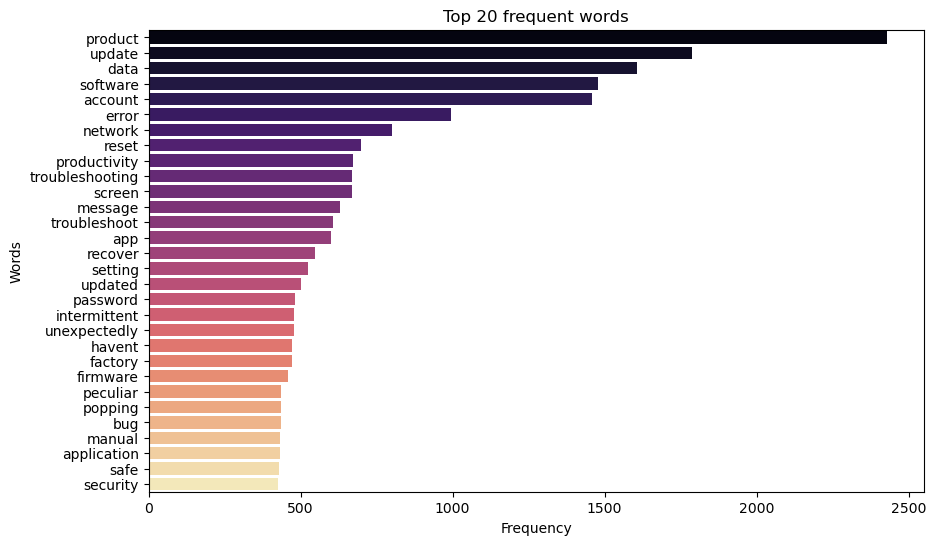

In [10]:
text_data = data_df['processed_text'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(30)

words, counts = zip(*common_words)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title("Top 20 frequent words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

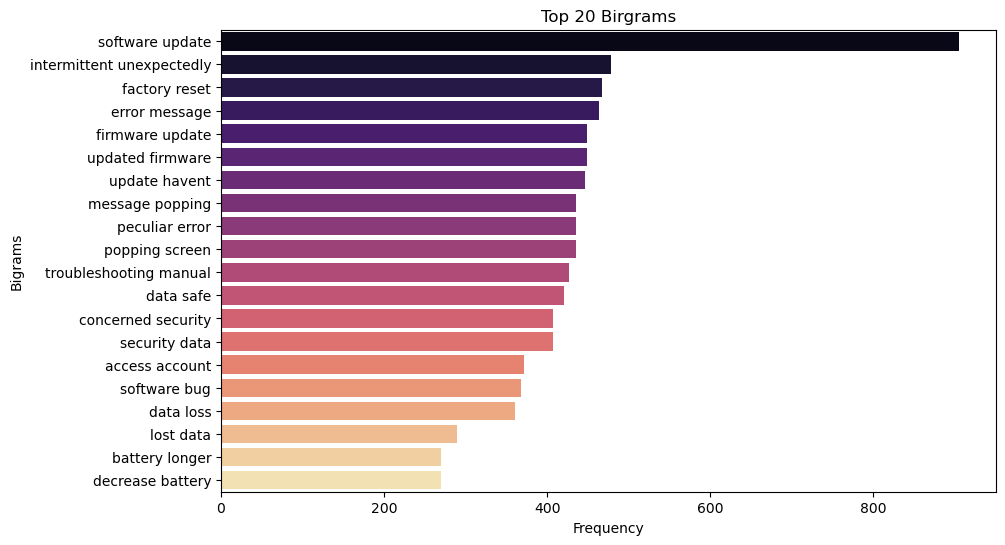

In [11]:
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma')
plt.title("Top 20 Birgrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()

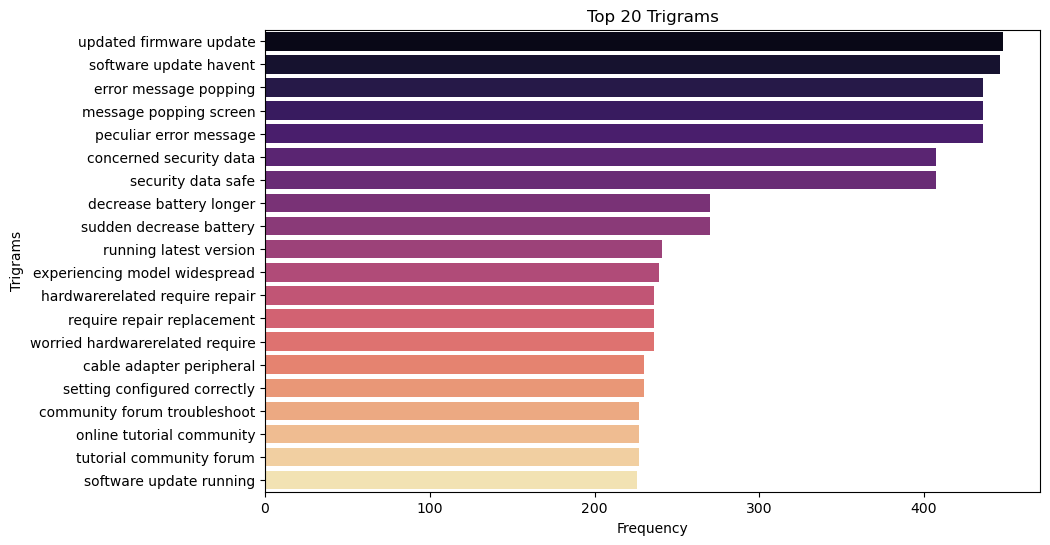

In [12]:
vectorizer = CountVectorizer(ngram_range=(3,3), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title("Top 20 Trigrams")
plt.xlabel("Frequency")
plt.ylabel("Trigrams")
plt.show()

In [13]:
ut.save_data(data_df, 'cleaned_data.csv')

Building the pipeline

In [14]:
def nlp_cleaner(text_list):
    results = []
    for text in text_list:
        cleaned = clean_text(text) 
        processed = preprocess(cleaned)
        results.append(processed)
    return results

### TFIDF

In [15]:
tfidf = TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7)

X = tfidf.fit_transform(data_df['processed_text'])

In [16]:
tfidf__preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner, validate=False)),
    ('tfidf', TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7))
])

### Embeddings

In [17]:
def clean_for_embeddings(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}|\[.*?\]|<.*?>|\(.*?\)', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # remove URLs
    text = re.sub(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', ' ', text) # remove email addresses
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # remove non-ASCII characters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [18]:
data_df['embedding_text'] = data_df['text'].apply(clean_for_embeddings)

In [19]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
embeddings = model.encode(data_df['embedding_text'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/253 [00:00<?, ?it/s]

In [21]:
embeddings = normalize(embeddings)

In [22]:
print(cosine_similarity([embeddings[0]], [embeddings[1]]))
print(cosine_similarity([embeddings[2]], [embeddings[5]]))

[[0.4405267]]
[[0.62984484]]


Building the pipeline

In [23]:
def nlp_cleaner_embeddings(text_list):
    results = []
    for text in text_list:
        cleaned = clean_for_embeddings(text) 
        results.append(cleaned)
    return results

In [24]:
embedding_preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner_embeddings, validate=False)),
    ('embeddings', md.SentenceEmbeddingTransformer(model_name='all-MiniLM-L6-v2')),
    ('normalize', Normalizer())
])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Modelling

### Baseline Model

#### Kmeans baseline testing model

  File "c:\Users\Shankar\.conda\envs\text_analytics\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Shankar\.conda\envs\text_analytics\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Shankar\.conda\envs\text_analytics\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Shankar\.conda\envs\text_analytics\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Shankar\.conda\envs\text_analytics\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^

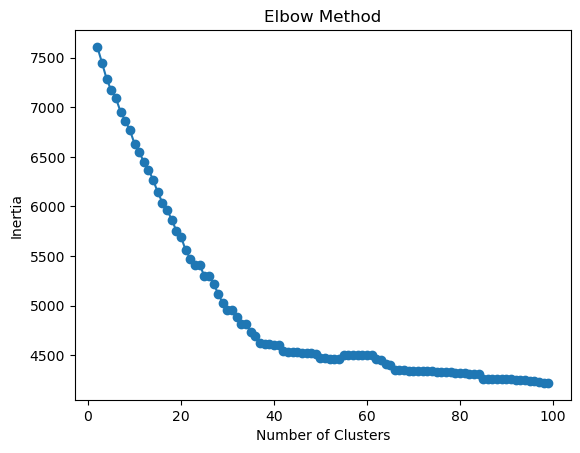

In [25]:
inertia = []

for k in range(2, 100):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(range(2,100), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [26]:
k = 10

kmeansbaseline = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeansbaseline.fit_predict(X)

array([0, 3, 0, ..., 6, 0, 4], shape=(8077,), dtype=int32)

In [27]:
terms = tfidf.get_feature_names_out()

def get_top_words_per_cluster(model, X, n=20):
    centroids = model.cluster_centers_
    
    for i in range(len(centroids)):
        top_indices = centroids[i].argsort()[-n:]
        top_words = [terms[j] for j in top_indices]
        
        print(f"\nCluster {i}:")
        print(top_words)

get_top_words_per_cluster(kmeansbaseline, X)


Cluster 0:
['model widespread', 'experiencing model', 'widespread', 'experiencing', 'model', 'charger', 'charger charging', 'setting configuration', 'app', 'troubleshooting website', 'configuration', 'purchase', 'charging', 'website', 'setting', 'manual', 'troubleshooting manual', 'troubleshooting', 'productivity', 'product']

Cluster 1:
['app', 'fix', 'update running', 'running latest', 'running', 'latest', 'latest version', 'version', 'product', 'software bug', 'bug', 'firmware update', 'updated firmware', 'firmware', 'updated', 'havent', 'update havent', 'software update', 'software', 'update']

Cluster 2:
['loss file', 'disappeared retrieve', 'document disappeared', 'file document', 'document', 'encountered data', 'encountered', 'retrieve', 'recover', 'lost data', 'lost', 'file', 'deleted', 'security', 'concerned', 'security data', 'concerned security', 'data safe', 'safe', 'data']

Cluster 3:
['locked unlock', 'logging account', 'reset', 'logging', 'account locked', 'account acco

In [28]:
labels = kmeansbaseline.labels_
distribution = pd.Series(labels).value_counts().sort_index()
print("Cluster Distribution:")
print(distribution)

Cluster Distribution:
0    3338
1    1330
2     771
3     680
4     311
5     237
6     323
7     523
8     381
9     183
Name: count, dtype: int64


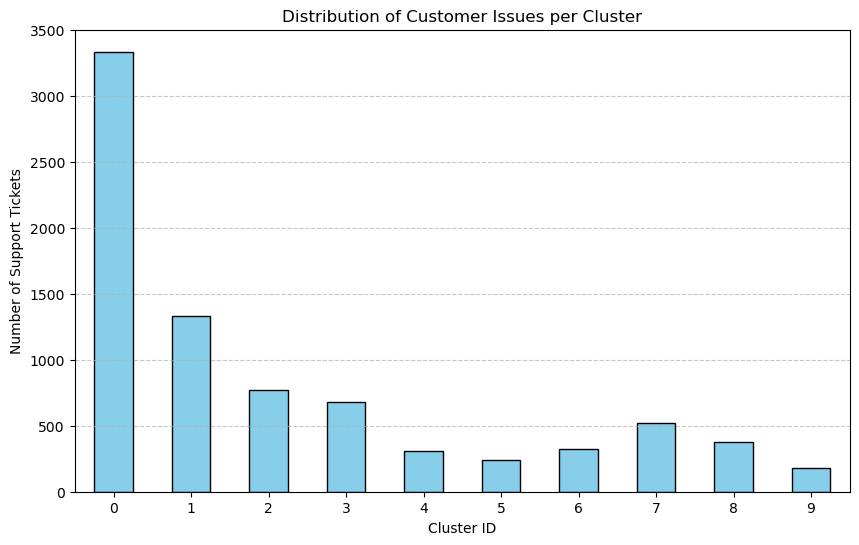

In [29]:
plt.figure(figsize=(10, 6))
distribution.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribution of Customer Issues per Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Support Tickets')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Kmeans

#### Kmeans with TFID without PCA

In [30]:
X_tfidf_raw = normalize(X).toarray()

In [31]:
def rkmeans(data_df, k, random_state=42):
    model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = model.fit_predict(data_df)
    return labels, model

In [32]:
def evaluate_k_range(data_df, k_range):
    k_list = list(k_range)
    cv_scores = []
    sil_scores = []
    inertia_scores = []

    print(f"{'k':<5} | {'CV (lower is better)':<22} | {'silhouette score (higher is better)':<22} | {'Inertia (lower is better)':<22}")
    print("-" * 55) 
    for k in k_list:
        labels, model = rkmeans(data_df, k)
        sizes = pd.Series(labels).value_counts()
        cv_score = sizes.std() / sizes.mean()
        cv_scores.append(cv_score)
        sil_score = silhouette_score(data_df, labels)
        sil_scores.append(sil_score)
        inertia_scores.append(model.inertia_)
        print(f"{k:<5} | {cv_score:<22.4f} | {sil_score:<22.4f} | {model.inertia_:<22.4f}")
    best_k_cv = k_list[np.argmin(cv_scores)]
    best_k_sil = k_list[np.argmax(sil_scores)]
    results = {
        'k_list': k_list,
        'cv': cv_scores,
        'silhouette': sil_scores,
        'inertia': inertia_scores,
        'best_k_cv': best_k_cv,
        'best_k_sil': best_k_sil
    }
    return results

In [33]:
def plot_combined_metrics(results, modelname):
    k_list = results['k_list']
    fig, (ax_cv, ax_elbow) = plt.subplots(2, 1, figsize=(12, 14))
    color_cv = 'blue'
    ax_cv.set_xlabel('Number of Clusters')
    ax_cv.set_ylabel('CV', color=color_cv, fontsize=11)
    ln1 = ax_cv.plot(k_list, results['cv'], 'o-', color=color_cv, label='CV', linewidth=2)
    ax_cv.tick_params(axis='y', labelcolor=color_cv)
    ax_cv_tw = ax_cv.twinx()
    color_sil = 'orange'
    ax_cv_tw.set_ylabel('Silhouette', color=color_sil, fontsize=11)
    ln2 = ax_cv_tw.plot(k_list, results['silhouette'], 's-', color=color_sil, label='Silhouette', linewidth=2)
    ax_cv_tw.tick_params(axis='y', labelcolor=color_sil)
    ax_cv.set_title(f'Kmeans with {modelname}: CV vs Silhouette', fontsize=14, fontweight='bold')
    ax_cv.grid(True, alpha=0.3)

    lns_1 = ln1 + ln2
    ax_cv.legend(lns_1, [l.get_label() for l in lns_1], loc='upper center')

    color_elb = 'red'
    ax_elbow.set_xlabel('Number of Clusters')
    ax_elbow.set_ylabel('Inertia or Elbow Plot', color=color_elb, fontsize=11)
    ln3 = ax_elbow.plot(k_list, results['inertia'], 'd-', color=color_elb, label='Inertia', linewidth=2)
    ax_elbow.tick_params(axis='y', labelcolor=color_elb)
    
    ax_elb_tw = ax_elbow.twinx()
    ax_elb_tw.set_ylabel('Silhouette', color=color_sil, fontsize=11)
    ln4 = ax_elb_tw.plot(k_list, results['silhouette'], 's-', color=color_sil, label='Silhouette', linewidth=2)
    ax_elb_tw.tick_params(axis='y', labelcolor=color_sil)
    
    ax_elbow.set_title(f'Kmeans with {modelname}: Elbow vs Silhouette', fontsize=14, fontweight='bold')
    ax_elbow.grid(True, alpha=0.3)
    lns_2 = ln3 + ln4
    ax_elbow.legend(lns_2, [l.get_label() for l in lns_2], loc='upper center')

    plt.tight_layout()
    plt.show()

In [34]:
def plot_cluster_distribution(data_df, k_list, modelname):
    num_plots = len(k_list)
    fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4), sharey=False)
    if num_plots == 1:
        axes = [axes]
    fig.suptitle(f'Cluster Size Distribution: {modelname}', fontsize=14, fontweight='bold', y=1.05)
    for i, k in enumerate(k_list):
        labels, _ = rkmeans(data_df, k)
        sizes = pd.Series(labels).value_counts().sort_index()
        cv = sizes.std() / sizes.mean()
        sil_score = silhouette_score(data_df, labels)
        axes[i].bar(sizes.index.astype(str), sizes.values, color=sns.color_palette('Blues_d', k))
        axes[i].set_title(f'k={k}\nCV={cv:.3f}\nSilhouette={sil_score:.3f}', fontsize=11)
        axes[i].set_xlabel('Cluster ID')
        axes[i].tick_params(axis='x', rotation=45)
        if i == 0:
            axes[i].set_ylabel('Number of Tickets')
    plt.tight_layout()
    plt.show()

In [35]:
def get_top_keywords(text_series, n=20):
    words = ' '.join(text_series).split()
    words = [w for w in words if len(w) > 3 and not w.isnumeric()]
    return [w for w, _ in Counter(words).most_common(n)]

def extract_cluster_topics(df, labels, k):
    clusters = {}
    labels_arr = np.array(labels)
    for i in range(k):
        docs = df[labels_arr == i]
        kw = get_top_keywords(docs['processed_text'])
        clusters[i] = kw
        print(f"Cluster {i:02d} (n={len(docs):4d}): {', '.join(kw)}")
        
    return clusters

In [36]:
def plot_clusters_2d(data_df, labels, k_value, modelname):
    pca_2d = PCA(n_components=2, random_state=42).fit_transform(data_df)
    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(pca_2d[:, 0], pca_2d[:, 1], c=labels, cmap='tab10', s=5, alpha=0.6)
    ax.set_title(f'{modelname}: 2D Cluster Visualisation (k={k_value})', fontsize=12)
    plt.colorbar(sc, ax=ax, label='Cluster')
    plt.show()

In [37]:
kvalues = range(2, 21)
resultofrun = evaluate_k_range(X_tfidf_raw, kvalues)

k     | CV (lower is better)   | silhouette score (higher is better) | Inertia (lower is better)
-------------------------------------------------------
2     | 0.8108                 | 0.0215                 | 7601.4168             
3     | 0.9445                 | 0.0310                 | 7443.2712             
4     | 0.9521                 | 0.0389                 | 7315.9929             
5     | 1.2849                 | 0.0460                 | 7182.7317             
6     | 1.2365                 | 0.0535                 | 7059.8827             
7     | 1.2301                 | 0.0620                 | 6928.1906             
8     | 1.1955                 | 0.0695                 | 6812.0110             
9     | 1.0770                 | 0.0734                 | 6715.0681             
10    | 1.1438                 | 0.0840                 | 6607.0085             
11    | 1.1702                 | 0.0904                 | 6516.1368             
12    | 1.4484                 | 0.09

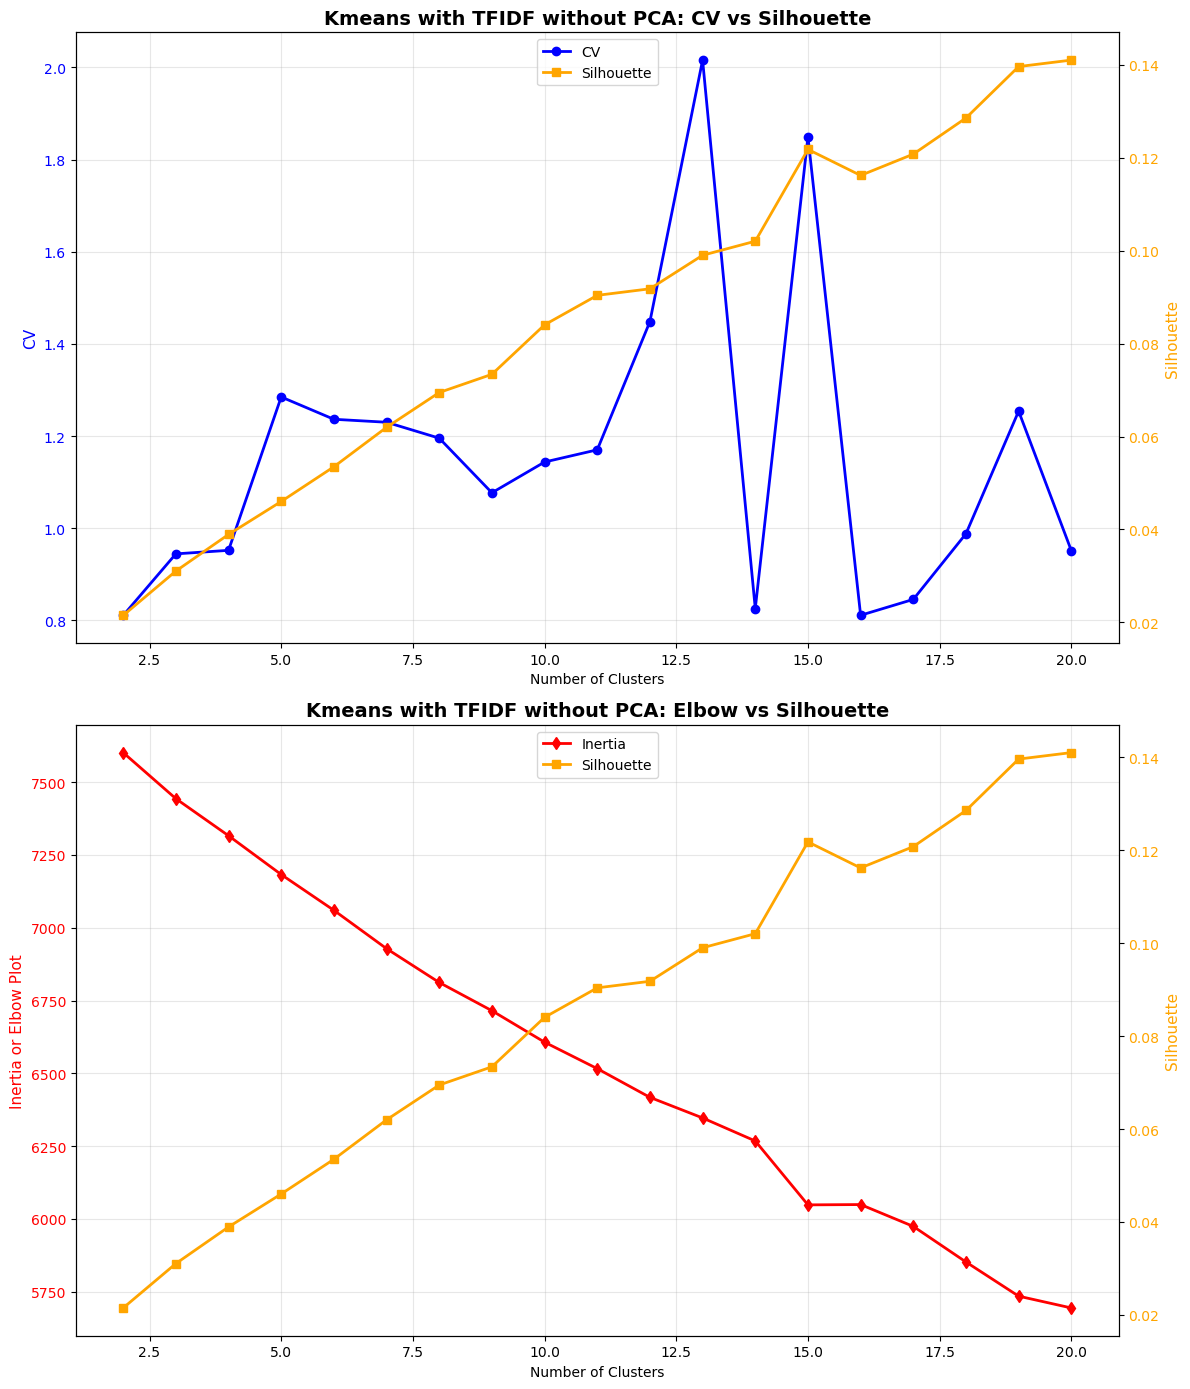

In [38]:
plot_combined_metrics(resultofrun, 'TFIDF without PCA')

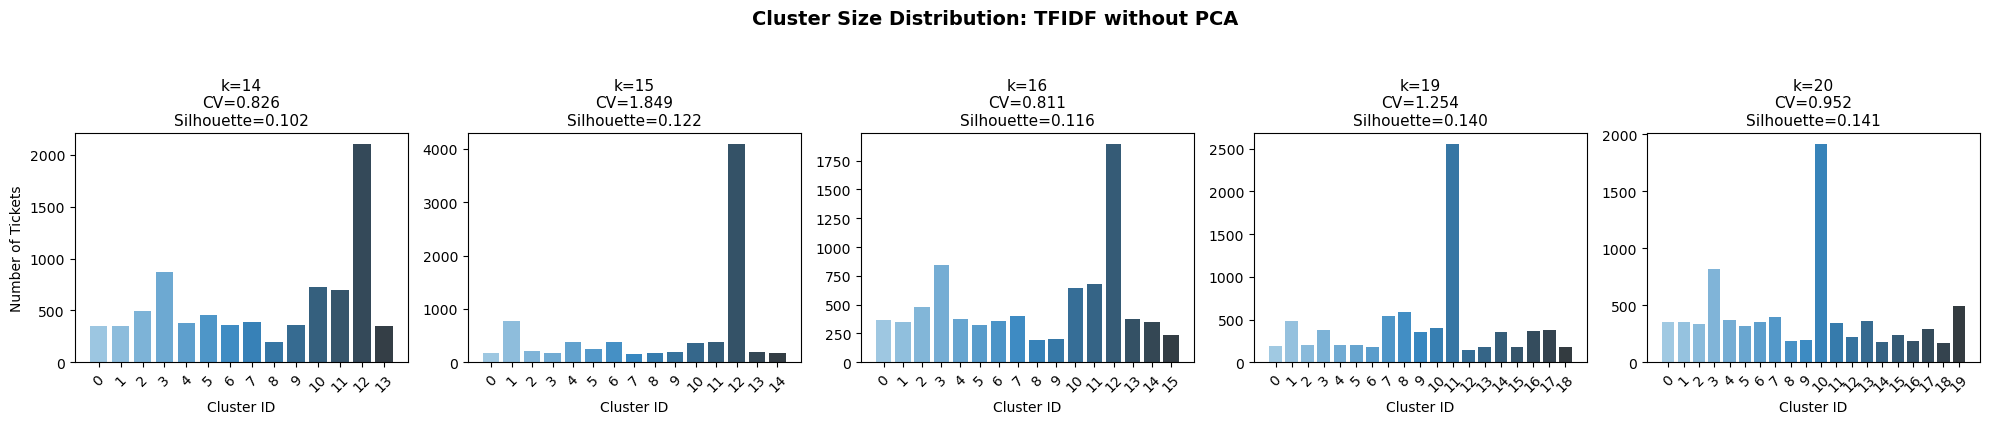

In [39]:
kvluestoplot = [14,15,16,19,20]
plot_cluster_distribution(X_tfidf_raw, kvluestoplot, 'TFIDF without PCA')

In [40]:
CPU_WATTS = 25
start_time = time.time()
fklabels, _ = rkmeans(X_tfidf_raw, k=14)
end_time = time.time()
duration = end_time - start_time
energy_kwh = (CPU_WATTS * duration) / 3600000
print(f"Execution Time: {duration:.2f} seconds")
print(f"Estimated Energy: {energy_kwh:.8f} kWh")


Execution Time: 6.76 seconds
Estimated Energy: 0.00004695 kWh


Please note that the values never remain the same but over multiple run we can estimate that this is the approx values  
k = 14  
Execution Time: 5.06 seconds
Estimated Energy: 0.00003516 kWh 
k = 16   
Execution Time: 5.66 seconds  
Estimated Energy: 0.00003930 kWh  
k = 20  
Execution Time: 6.32 seconds  
Estimated Energy: 0.00004389 kWh  

In [41]:
kmeansbaseclusters = extract_cluster_topics(data_df, fklabels, 14)

Cluster 00 (n= 352): update, updated, firmware, product, software, purchase, hardware, difficult, address, glitch, freeze, frequently, page, question, current, error, sorry, package, number, service
Cluster 01 (n= 352): account, access, error, correct, login, invalid, regain, displaying, credential, occurs, consistently, feature, application, product, update, troubleshooting, data, updated, software, purchased
Cluster 02 (n= 498): data, file, deleted, loss, software, error, important, accidentally, recover, retrieve, causing, unexpected, encountered, document, urgently, disappeared, update, productivity, troubleshooting, setting
Cluster 03 (n= 875): update, software, havent, product, version, running, latest, application, crash, encountering, purchase, hardware, purchased, network, connect, respond, yesterday, difficult, fails, list
Cluster 04 (n= 378): error, screen, message, peculiar, popping, product, hardware, account, software, update, data, purchase, strange, noise, functioning, 

Even though cluster value of 16 is superior which has higher silhouette score and lower cv value it doesnt form good clusters. Cluster value of 14 have given best clusters. Clusters with value 20 often segregates a lot where the difference between the clusters become a noise.

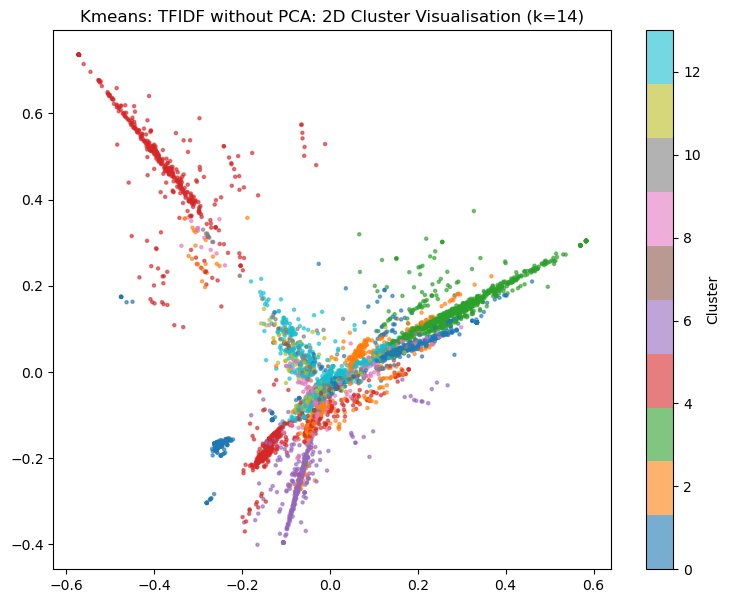

In [42]:
plot_clusters_2d(X_tfidf_raw, fklabels, 14, 'Kmeans: TFIDF without PCA')

TFIDF + PCA + Kmeans

In [43]:
def prepare_tfidf_pca(X_tfidf, n_components=0.95):
    pca = PCA(n_components=n_components, random_state=42)
    
    if hasattr(X_tfidf, "toarray"):
        X_pca = pca.fit_transform(X_tfidf.toarray())
    else:
        X_pca = pca.fit_transform(X_tfidf)
        
    print(f"TF-IDF Original Features: {X_tfidf.shape[1]}")
    print(f"PCA Reduced Components:   {X_pca.shape[1]} (retains {n_components*100}% variance)")
    
    return X_pca, pca

In [44]:
x_tfidf_pca, tfidf_pca_model = prepare_tfidf_pca(X_tfidf_raw)

TF-IDF Original Features: 1000
PCA Reduced Components:   594 (retains 95.0% variance)


In [45]:
kvalues = range(2, 21)
resultofrunfortfidfpca = evaluate_k_range(x_tfidf_pca, kvalues)

k     | CV (lower is better)   | silhouette score (higher is better) | Inertia (lower is better)
-------------------------------------------------------
2     | 1.2262                 | 0.0237                 | 7212.8891             
3     | 1.0567                 | 0.0304                 | 7069.1481             
4     | 1.1687                 | 0.0376                 | 6954.2345             
5     | 1.5033                 | 0.0489                 | 6821.9794             
6     | 1.6186                 | 0.0597                 | 6679.9781             
7     | 1.6684                 | 0.0661                 | 6562.1625             
8     | 1.3690                 | 0.0710                 | 6456.2280             
9     | 1.1422                 | 0.0771                 | 6356.8647             
10    | 1.1114                 | 0.0880                 | 6229.3088             
11    | 1.4458                 | 0.0940                 | 6111.9703             
12    | 2.0894                 | 0.10

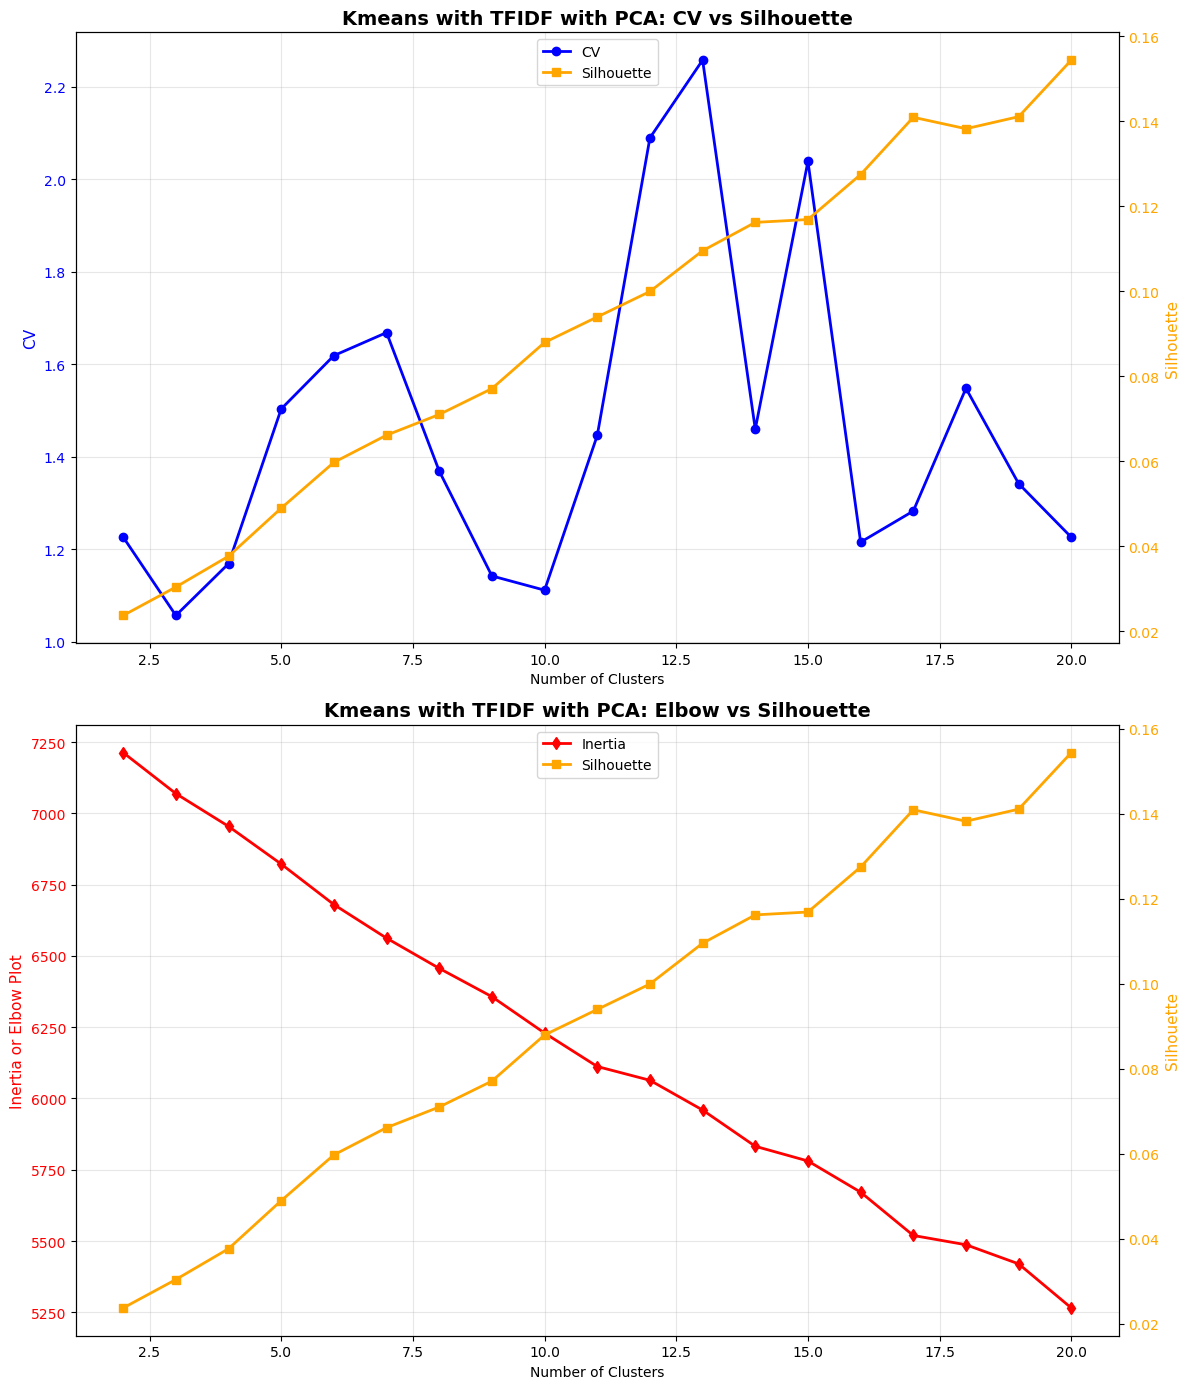

In [46]:
plot_combined_metrics(resultofrunfortfidfpca, 'TFIDF with PCA')

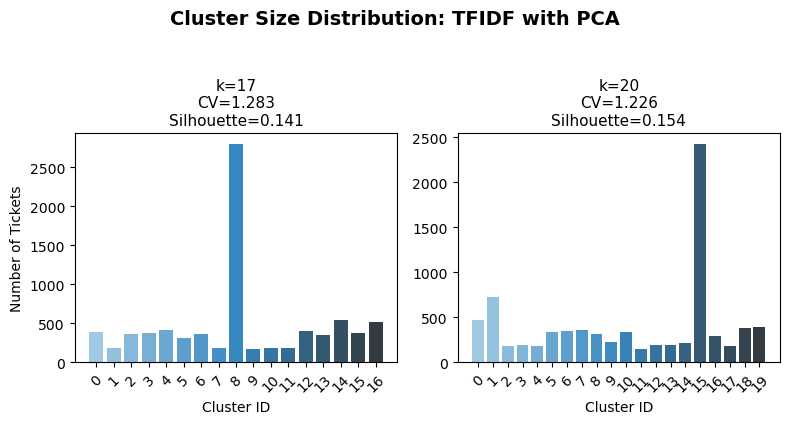

In [47]:
kvluestoplotfortfidfpca = [17,20]
plot_cluster_distribution(x_tfidf_pca, kvluestoplotfortfidfpca, 'TFIDF with PCA')

In [48]:
CPU_WATTS = 25
start_time = time.time()
fklabelstfidfpca, _ = rkmeans(x_tfidf_pca, k=17)
end_time = time.time()
duration = end_time - start_time
energy_kwh = (CPU_WATTS * duration) / 3600000
print(f"Execution Time: {duration:.2f} seconds")
print(f"Estimated Energy: {energy_kwh:.8f} kWh")

Execution Time: 4.77 seconds
Estimated Energy: 0.00003311 kWh


In [49]:
kmeansbaseclusterstfidfpca = extract_cluster_topics(data_df, fklabelstfidfpca, 17)

Cluster 00 (n= 385): software, update, version, latest, running, application, feature, occurs, consistently, product, account, purchase, purchased, file, message, list, sorry, unlock, crash, data
Cluster 01 (n= 180): network, connect, troubleshoot, fails, update, software, data, error, setting, troubleshooting, havent, peculiar, message, popping, screen, factory, reset, productivity, security, application
Cluster 02 (n= 358): error, screen, message, peculiar, popping, product, account, hardware, purchase, update, software, strange, noise, functioning, suspect, purchased, data, question, shipped, loss
Cluster 03 (n= 381): reset, factory, product, account, update, software, hardware, data, file, application, encountering, crash, refund, address, message, retrieve, locked, encountered, loss, document
Cluster 04 (n= 416): account, password, battery, longer, sudden, decrease, reset, recover, forgotten, product, update, software, login, address, screen, error, data, message, click, following

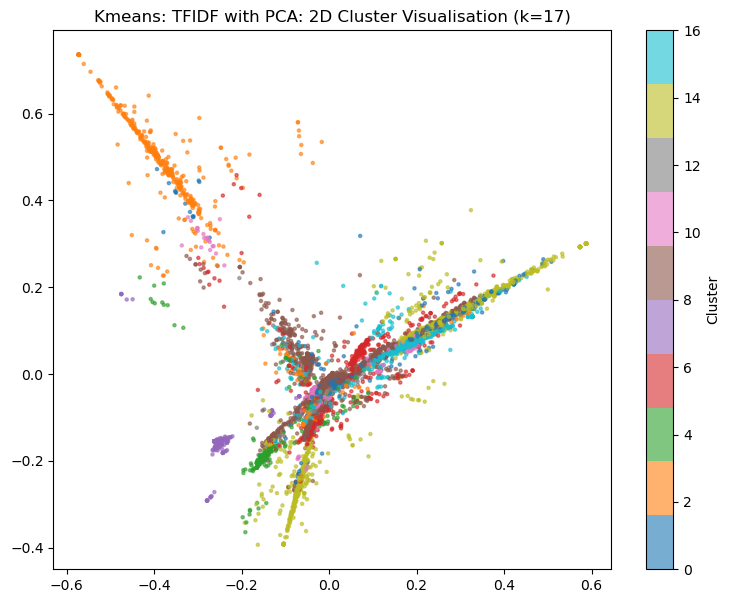

In [50]:
plot_clusters_2d(x_tfidf_pca, fklabelstfidfpca, 17, 'Kmeans: TFIDF with PCA')